# Week 7: Advanced Gradient-Boosting Models

## California Property Price Prediction

This notebook expands the property-price modeling workflow by
introducing two advanced gradient-boosting algorithms:

- XGBoost
- LightGBM

A scikit-learn Gradient Boosting model is also included as a reference.

## Objectives

1. Load the Week 6 feature-engineered datasets
2. Preserve the existing chronological test set
3. Create a chronological validation subset from the training data
4. Train Gradient Boosting, XGBoost, and LightGBM
5. Use early stopping for XGBoost and LightGBM
6. Evaluate the models using MAE, RMSE, MAPE, MdAPE, and R²
7. Compare training and prediction time
8. Analyze feature importance
9. Save all models and reports
10. Select the strongest model using test RMSE

The existing test set is not used for model fitting or early stopping.

In [2]:
%pip install xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from time import perf_counter
import json
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lightgbm import (
    LGBMRegressor,
    early_stopping as lgb_early_stopping,
    log_evaluation as lgb_log_evaluation,
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

In [4]:
import lightgbm
import sklearn
import xgboost

print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"XGBoost version: {xgboost.__version__}")
print(f"LightGBM version: {lightgbm.__version__}")

pandas version: 2.3.3
NumPy version: 1.26.4
scikit-learn version: 1.5.1
XGBoost version: 3.2.0
LightGBM version: 4.7.0


In [5]:
PROJECT_ROOT = Path.cwd().parent

# Handle cases where Jupyter starts in the project root.
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
SRC_DIR = PROJECT_ROOT / "src"

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

TRAIN_FILE = DATA_DIR / "train_features.csv"
TEST_FILE = DATA_DIR / "test_features.csv"

TARGET_COLUMN = "ClosePrice"
RANDOM_STATE = 42
VALIDATION_FRACTION = 0.20

print(f"Project root: {PROJECT_ROOT}")
print(f"Training file: {TRAIN_FILE}")
print(f"Testing file: {TEST_FILE}")

Project root: C:\Users\sonng\California_Housing_Data
Training file: C:\Users\sonng\California_Housing_Data\data\train_features.csv
Testing file: C:\Users\sonng\California_Housing_Data\data\test_features.csv


In [6]:
if not TRAIN_FILE.exists():
    raise FileNotFoundError(
        f"Training file was not found: {TRAIN_FILE}\n"
        "Run src/features.py before starting Week 7."
    )

if not TEST_FILE.exists():
    raise FileNotFoundError(
        f"Testing file was not found: {TEST_FILE}\n"
        "Run src/features.py before starting Week 7."
    )

train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

print(f"Training shape: {train_df.shape}")
print(f"Testing shape: {test_df.shape}")

train_df.head()

Training shape: (49703, 989)
Testing shape: (12024, 989)


,ClosePrice,LotSizeSquareFeet,LivingArea,BathroomsTotalInteger,BedroomsTotal,ListPrice,PropertyAge,City_Acampo,City_Acton,City_Adelanto,City_Agoura Hills,City_Agua Dulce,City_Aguanga,City_Ahwahnee,City_Alameda,City_Alamo,City_Albany,City_Albion,City_Alhambra,City_Aliso Viejo,City_Almanor,City_Alpine,City_Alta Loma,City_Altadena,City_Alturas,City_Alviso,City_American Canyon,City_Anaheim,City_Anaheim Hills,City_Anderson,City_Angels Camp,City_Angelus Oaks,City_Angwin,City_Antelope,City_Antioch,City_Anza,City_Apple Valley,City_Aptos,City_Arbuckle,City_Arcadia,City_Arleta,City_Arnold,City_Aromas,City_Arrowbear,City_Arroyo Grande,City_Artesia,City_Artois,City_Arvin,City_Atascadero,City_Atherton,City_Atwater,City_Atwater Village,City_Auberry,City_Auburn,City_Avalon,City_Avenal,City_Avila Beach,City_Azusa,City_Bakersfield,City_Baldwin Hills,City_Baldwin Park,City_Bangor,City_Banning,City_Barstow,City_Bass Lake,City_Bay Point,City_Beaumont,City_Bel Air,City_Bell,City_Bell Canyon,City_Bell Gardens,City_Bellflower,City_Belmont,City_Ben Lomond,City_Benicia,City_Berkeley,City_Bermuda Dunes,City_Berry Creek,City_Bethel Island,City_Beverly Hills,City_Big Bar,City_Big Bear,City_Big Bear City,City_Big Bear Lake,City_Big River,City_Big Sur,City_Biggs,City_Bishop,City_Bloomington,City_Blue Jay,City_Blythe,City_Bodfish,City_Bombay Beach,City_Bonita,City_Bonsall,City_Boron,City_Borrego Springs,City_Boulder Creek,City_Boulevard,City_Bradbury,...,City_Westwood,City_Wheatland,City_Whitewater,City_Whittier,City_Wildomar,City_Williams,City_Willits,City_Willows,City_Wilmington,City_Wilton,City_Winchester,City_Windsor Hills,City_Winnetka,City_Winton,City_Wishon,City_Wofford Heights,City_Woodbridge,City_Woodcrest,City_Woodland,City_Woodland Hills,City_Woodside,City_Wrightwood,City_Yermo,City_Yorba Linda,City_Yosemite,City_Yreka,City_Yuba City,City_Yucaipa,City_Yucca Valley,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,CountyOrParish_San Luis Obispo,CountyOrParish_San Mateo,CountyOrParish_Santa Barbara,CountyOrParish_Santa Clara,CountyOrParish_Santa Cruz,CountyOrParish_Shasta,CountyOrParish_Siskiyou,CountyOrParish_Solano,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,LivingAreaPerBedroom,LivingAreaPerBathroom,BedBathRatio,ListPricePerSquareFoot,LotToLivingAreaRatio,TotalRoomsApprox,OutdoorSpaceApprox,LogLivingArea,LogLotSize,LogListPrice,IsNewProperty,IsRecentProperty,IsOlderProperty,PropertyAgeSquared
0,"1,998,000.0000","10,080.0000","2,045.0000",2.0000,4.0000,"1,998,000.0000",57.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

In [7]:
if TARGET_COLUMN not in train_df.columns:
    raise ValueError(
        f"{TARGET_COLUMN} is missing from the training data."
    )

if TARGET_COLUMN not in test_df.columns:
    raise ValueError(
        f"{TARGET_COLUMN} is missing from the testing data."
    )

if train_df.empty:
    raise ValueError("The training dataset is empty.")

if test_df.empty:
    raise ValueError("The testing dataset is empty.")

if train_df.columns.duplicated().any():
    raise ValueError(
        "The training dataset contains duplicate columns."
    )

if test_df.columns.duplicated().any():
    raise ValueError(
        "The testing dataset contains duplicate columns."
    )

print("Dataset structure passed validation.")

Dataset structure passed validation.


In [8]:
dtype_summary = pd.DataFrame(
    {
        "Column": train_df.columns,
        "DataType": train_df.dtypes.astype(str).values,
        "MissingValues": train_df.isna().sum().values,
        "UniqueValues": [
            train_df[column].nunique(dropna=True)
            for column in train_df.columns
        ],
    }
)

dtype_summary

,Column,DataType,MissingValues,UniqueValues
0,ClosePrice,float64,0,6306
1,LotSizeSquareFeet,float64,0,12950
2,LivingArea,float64,0,4773
3,BathroomsTotalInteger,float64,0,17
4,BedroomsTotal,float64,0,15
...,...,...,...,...
984,LogListPrice,float64,0,5534
985,IsNewProperty,int64,0,2
986,IsRecentProperty,int64,0,2
987,IsOlderProperty,int64,0,2


In [9]:
X_train_raw = train_df.drop(
    columns=[TARGET_COLUMN]
)

y_train = pd.to_numeric(
    train_df[TARGET_COLUMN],
    errors="coerce",
)

X_test_raw = test_df.drop(
    columns=[TARGET_COLUMN]
)

y_test = pd.to_numeric(
    test_df[TARGET_COLUMN],
    errors="coerce",
)

if y_train.isna().any():
    raise ValueError(
        "The training target contains missing or invalid values."
    )

if y_test.isna().any():
    raise ValueError(
        "The testing target contains missing or invalid values."
    )

print(f"Raw training predictors: {X_train_raw.shape}")
print(f"Raw testing predictors: {X_test_raw.shape}")
print(f"Training target: {y_train.shape}")
print(f"Testing target: {y_test.shape}")

Raw training predictors: (49703, 988)
Raw testing predictors: (12024, 988)
Training target: (49703,)
Testing target: (12024,)


In [10]:
X_train, X_test = X_train_raw.align(
    X_test_raw,
    join="left",
    axis=1,
    fill_value=0,
)

for column in X_train.columns:
    X_train[column] = pd.to_numeric(
        X_train[column],
        errors="coerce",
    )

    X_test[column] = pd.to_numeric(
        X_test[column],
        errors="coerce",
    )

    training_median = X_train[column].median()

    if pd.isna(training_median):
        training_median = 0.0

    X_train[column] = (
        X_train[column]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(training_median)
        .astype(float)
    )

    X_test[column] = (
        X_test[column]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(training_median)
        .astype(float)
    )

print(f"Numeric training predictors: {X_train.shape}")
print(f"Numeric testing predictors: {X_test.shape}")

print(
    "Training missing values:",
    int(X_train.isna().sum().sum()),
)

print(
    "Testing missing values:",
    int(X_test.isna().sum().sum()),
)

Numeric training predictors: (49703, 988)
Numeric testing predictors: (12024, 988)
Training missing values: 0
Testing missing values: 0


In [11]:
train_array = X_train.to_numpy(dtype=float)
test_array = X_test.to_numpy(dtype=float)

if np.isnan(train_array).any():
    raise ValueError(
        "Training predictors still contain NaN values."
    )

if np.isnan(test_array).any():
    raise ValueError(
        "Testing predictors still contain NaN values."
    )

if np.isinf(train_array).any():
    raise ValueError(
        "Training predictors contain infinite values."
    )

if np.isinf(test_array).any():
    raise ValueError(
        "Testing predictors contain infinite values."
    )

if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "Training and testing predictor columns do not match."
    )

print("Model matrices passed numeric validation.")

Model matrices passed numeric validation.


## Chronological Validation Strategy

The original Week 3 time-based test set remains untouched.

For early stopping, the final 20% of the training observations is used
as a validation subset. The data is not shuffled, so the validation
period remains later than the model-fitting period.

In [13]:
split_index = int(
    len(X_train) * (1 - VALIDATION_FRACTION)
)

if split_index <= 0 or split_index >= len(X_train):
    raise ValueError(
        "The validation split produced an empty subset."
    )

X_fit = X_train.iloc[:split_index].copy()
X_validation = X_train.iloc[split_index:].copy()

y_fit = y_train.iloc[:split_index].copy()
y_validation = y_train.iloc[split_index:].copy()

print(f"Model-fitting observations: {len(X_fit):,}")
print(f"Validation observations: {len(X_validation):,}")
print(f"Final test observations: {len(X_test):,}")

print(
    "\nValidation share:",
    f"{len(X_validation) / len(X_train):.2%}",
)

Model-fitting observations: 39,762
Validation observations: 9,941
Final test observations: 12,024

Validation share: 20.00%


In [14]:
def calculate_mape(actual, predicted):
    """
    Calculate Mean Absolute Percentage Error.
    """

    actual_array = np.asarray(
        actual,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted,
        dtype=float,
    )

    valid_mask = (
        np.isfinite(actual_array)
        & np.isfinite(predicted_array)
        & (actual_array != 0)
    )

    if not np.any(valid_mask):
        return np.nan

    percentage_errors = np.abs(
        (
            actual_array[valid_mask]
            - predicted_array[valid_mask]
        )
        / actual_array[valid_mask]
    )

    return float(
        np.mean(percentage_errors) * 100
    )


def calculate_mdape(actual, predicted):
    """
    Calculate Median Absolute Percentage Error.
    """

    actual_array = np.asarray(
        actual,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted,
        dtype=float,
    )

    valid_mask = (
        np.isfinite(actual_array)
        & np.isfinite(predicted_array)
        & (actual_array != 0)
    )

    if not np.any(valid_mask):
        return np.nan

    percentage_errors = np.abs(
        (
            actual_array[valid_mask]
            - predicted_array[valid_mask]
        )
        / actual_array[valid_mask]
    )

    return float(
        np.median(percentage_errors) * 100
    )


def calculate_metrics(actual, predicted):
    """
    Return all regression evaluation metrics.
    """

    return {
        "MAE": float(
            mean_absolute_error(
                actual,
                predicted,
            )
        ),
        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    actual,
                    predicted,
                )
            )
        ),
        "MAPE": calculate_mape(
            actual,
            predicted,
        ),
        "MdAPE": calculate_mdape(
            actual,
            predicted,
        ),
        "R2": float(
            r2_score(
                actual,
                predicted,
            )
        ),
    }

In [15]:
reference_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    loss="squared_error",
    random_state=RANDOM_STATE,
)

reference_model

GradientBoostingRegressor(learning_rate=0.05, min_samples_leaf=5,
                          min_samples_split=10, n_estimators=300,
                          random_state=42)

In [16]:
xgboost_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    early_stopping_rounds=75,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgboost_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=75,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [17]:
lightgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

lightgbm_model

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=2000,
              n_jobs=-1, objective='regression', random_state=42,
              reg_lambda=1.0, subsample=0.8, verbosity=-1)

In [18]:
reference_start = perf_counter()

reference_model.fit(
    X_fit,
    y_fit,
)

reference_training_seconds = (
    perf_counter() - reference_start
)

print(
    "Reference model training time:",
    f"{reference_training_seconds:.2f} seconds",
)

Reference model training time: 194.15 seconds


In [19]:
xgboost_start = perf_counter()

xgboost_model.fit(
    X_fit,
    y_fit,
    eval_set=[
        (
            X_validation,
            y_validation,
        )
    ],
    verbose=False,
)

xgboost_training_seconds = (
    perf_counter() - xgboost_start
)

print(
    "XGBoost training time:",
    f"{xgboost_training_seconds:.2f} seconds",
)

if hasattr(xgboost_model, "best_iteration"):
    print(
        "XGBoost best iteration:",
        xgboost_model.best_iteration,
    )

if hasattr(xgboost_model, "best_score"):
    print(
        "XGBoost best validation score:",
        xgboost_model.best_score,
    )

XGBoost training time: 6.01 seconds
XGBoost best iteration: 71
XGBoost best validation score: 12804286.78894047


In [20]:
lightgbm_callbacks = [
    lgb_early_stopping(
        stopping_rounds=75,
        first_metric_only=True,
        verbose=False,
    ),
    lgb_log_evaluation(
        period=0,
    ),
]

lightgbm_start = perf_counter()

lightgbm_model.fit(
    X_fit,
    y_fit,
    eval_set=[
        (
            X_validation,
            y_validation,
        )
    ],
    eval_metric="rmse",
    callbacks=lightgbm_callbacks,
)

lightgbm_training_seconds = (
    perf_counter() - lightgbm_start
)

print(
    "LightGBM training time:",
    f"{lightgbm_training_seconds:.2f} seconds",
)

if hasattr(lightgbm_model, "best_iteration_"):
    print(
        "LightGBM best iteration:",
        lightgbm_model.best_iteration_,
    )

LightGBM training time: 0.83 seconds
LightGBM best iteration: 42


In [21]:
trained_models = {
    "Gradient Boosting Reference": reference_model,
    "XGBoost": xgboost_model,
    "LightGBM": lightgbm_model,
}

training_times = {
    "Gradient Boosting Reference": (
        reference_training_seconds
    ),
    "XGBoost": xgboost_training_seconds,
    "LightGBM": lightgbm_training_seconds,
}

test_predictions = {}
prediction_times = {}

for model_name, model in trained_models.items():
    prediction_start = perf_counter()

    predictions = model.predict(X_test)

    prediction_seconds = (
        perf_counter() - prediction_start
    )

    test_predictions[model_name] = predictions
    prediction_times[model_name] = prediction_seconds

    print(
        f"{model_name}: "
        f"{prediction_seconds:.4f} prediction seconds"
    )

Gradient Boosting Reference: 0.4246 prediction seconds
XGBoost: 0.1000 prediction seconds
LightGBM: 0.0809 prediction seconds


In [22]:
metrics_rows = []

for model_name, predictions in test_predictions.items():
    model_metrics = calculate_metrics(
        actual=y_test,
        predicted=predictions,
    )

    metrics_rows.append(
        {
            "Model": model_name,
            **model_metrics,
            "TrainingSeconds": training_times[model_name],
            "PredictionSeconds": prediction_times[model_name],
        }
    )

advanced_metrics = pd.DataFrame(
    metrics_rows
)

advanced_metrics = advanced_metrics.sort_values(
    by=["RMSE", "R2"],
    ascending=[True, False],
).reset_index(drop=True)

advanced_metrics

,Model,MAE,RMSE,MAPE,MdAPE,R2,TrainingSeconds,PredictionSeconds
0,LightGBM,"284,937.7095","1,226,080.4285",35.9676,15.7095,0.4661,0.8301,0.0809
1,Gradient Boosting Reference,"176,527.7544","1,481,924.6953",23.2542,6.1594,0.2201,194.1487,0.4246
2,XGBoost,"206,220.8425","1,657,109.9678",28.4073,7.7660,0.0248,6.0096,0.1000


In [23]:
formatted_metrics = advanced_metrics.copy()

formatted_metrics["MAE"] = formatted_metrics["MAE"].map(
    lambda value: f"${value:,.2f}"
)

formatted_metrics["RMSE"] = formatted_metrics["RMSE"].map(
    lambda value: f"${value:,.2f}"
)

formatted_metrics["MAPE"] = formatted_metrics["MAPE"].map(
    lambda value: f"{value:.2f}%"
)

formatted_metrics["MdAPE"] = formatted_metrics["MdAPE"].map(
    lambda value: f"{value:.2f}%"
)

formatted_metrics["R2"] = formatted_metrics["R2"].map(
    lambda value: f"{value:.4f}"
)

formatted_metrics["TrainingSeconds"] = (
    formatted_metrics["TrainingSeconds"].map(
        lambda value: f"{value:.2f}"
    )
)

formatted_metrics["PredictionSeconds"] = (
    formatted_metrics["PredictionSeconds"].map(
        lambda value: f"{value:.4f}"
    )
)

formatted_metrics

,Model,MAE,RMSE,MAPE,MdAPE,R2,TrainingSeconds,PredictionSeconds
0,LightGBM,"$284,937.71","$1,226,080.43",35.97%,15.71%,0.4661,0.83,0.0809
1,Gradient Boosting Reference,"$176,527.75","$1,481,924.70",23.25%,6.16%,0.2201,194.15,0.4246
2,XGBoost,"$206,220.84","$1,657,109.97",28.41%,7.77%,0.0248,6.01,0.1000


In [24]:
best_model_name = advanced_metrics.loc[
    0,
    "Model",
]

best_model = trained_models[
    best_model_name
]

best_metrics = advanced_metrics.iloc[0]

print(f"Best Week 7 model: {best_model_name}")
print(f"MAE: ${best_metrics['MAE']:,.2f}")
print(f"RMSE: ${best_metrics['RMSE']:,.2f}")
print(f"MAPE: {best_metrics['MAPE']:.2f}%")
print(f"MdAPE: {best_metrics['MdAPE']:.2f}%")
print(f"R²: {best_metrics['R2']:.4f}")

Best Week 7 model: LightGBM
MAE: $284,937.71
RMSE: $1,226,080.43
MAPE: 35.97%
MdAPE: 15.71%
R²: 0.4661


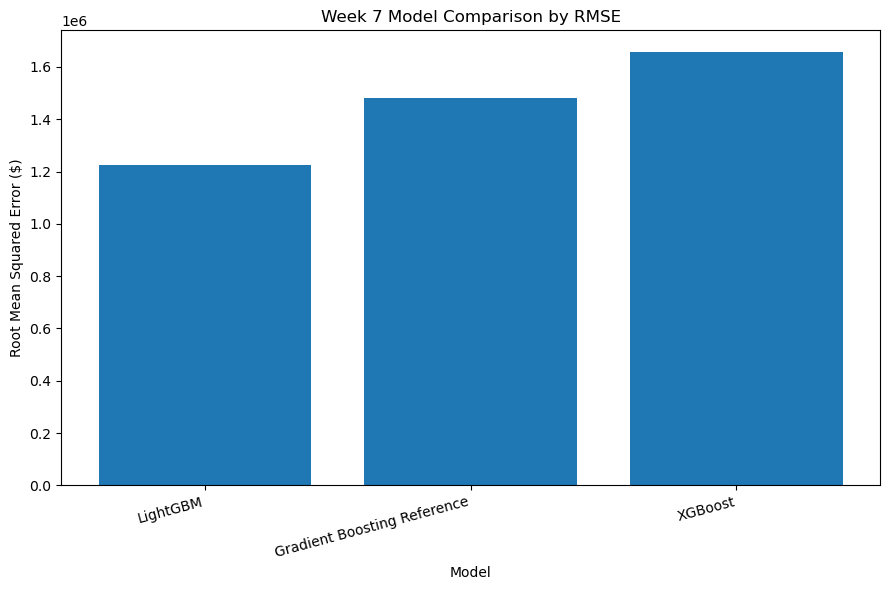

In [25]:
plot_metrics = advanced_metrics.sort_values(
    by="RMSE",
    ascending=True,
)

plt.figure(figsize=(9, 6))

plt.bar(
    plot_metrics["Model"],
    plot_metrics["RMSE"],
)

plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error ($)")
plt.title("Week 7 Model Comparison by RMSE")

plt.xticks(
    rotation=15,
    ha="right",
)

plt.tight_layout()
plt.show()

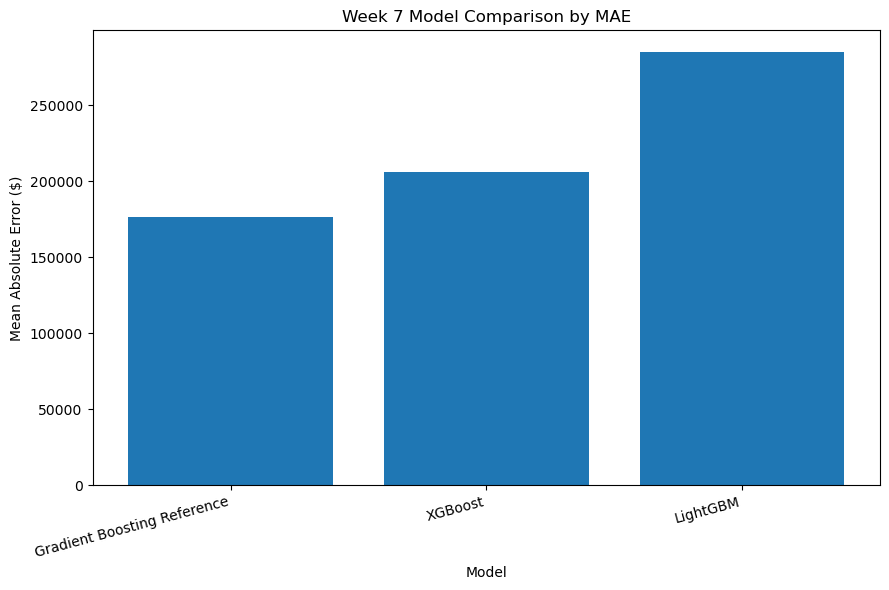

In [26]:
plot_metrics = advanced_metrics.sort_values(
    by="MAE",
    ascending=True,
)

plt.figure(figsize=(9, 6))

plt.bar(
    plot_metrics["Model"],
    plot_metrics["MAE"],
)

plt.xlabel("Model")
plt.ylabel("Mean Absolute Error ($)")
plt.title("Week 7 Model Comparison by MAE")

plt.xticks(
    rotation=15,
    ha="right",
)

plt.tight_layout()
plt.show()

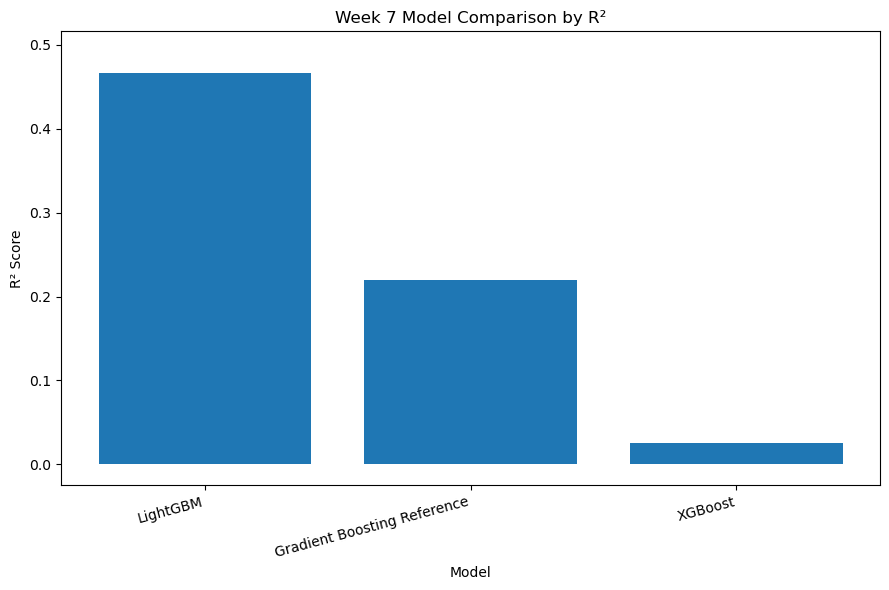

In [27]:
plot_metrics = advanced_metrics.sort_values(
    by="R2",
    ascending=False,
)

plt.figure(figsize=(9, 6))

plt.bar(
    plot_metrics["Model"],
    plot_metrics["R2"],
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Week 7 Model Comparison by R²")

plt.xticks(
    rotation=15,
    ha="right",
)

lower_limit = min(
    0,
    plot_metrics["R2"].min() - 0.05,
)

upper_limit = min(
    1,
    plot_metrics["R2"].max() + 0.05,
)

plt.ylim(
    lower_limit,
    upper_limit,
)

plt.tight_layout()
plt.show()

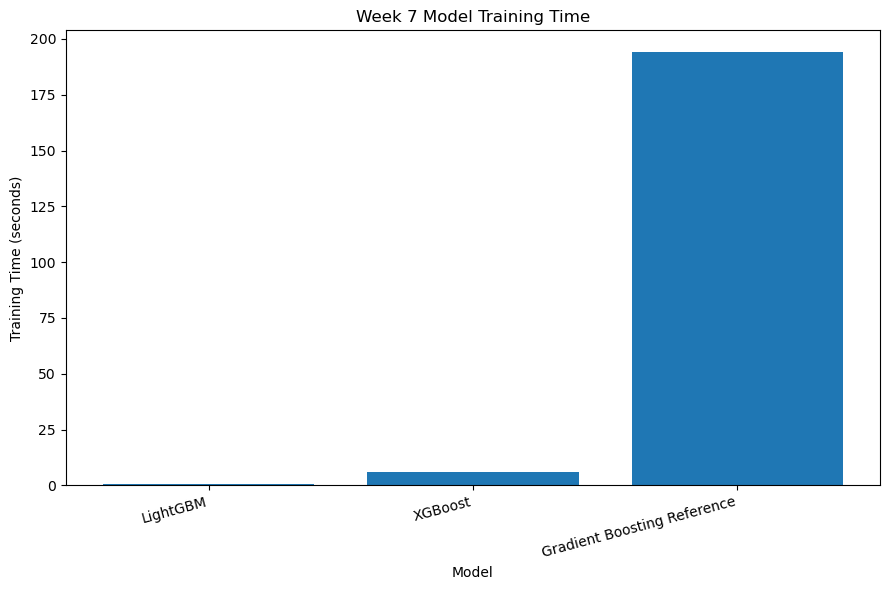

In [28]:
time_metrics = advanced_metrics.sort_values(
    by="TrainingSeconds",
    ascending=True,
)

plt.figure(figsize=(9, 6))

plt.bar(
    time_metrics["Model"],
    time_metrics["TrainingSeconds"],
)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Week 7 Model Training Time")

plt.xticks(
    rotation=15,
    ha="right",
)

plt.tight_layout()
plt.show()

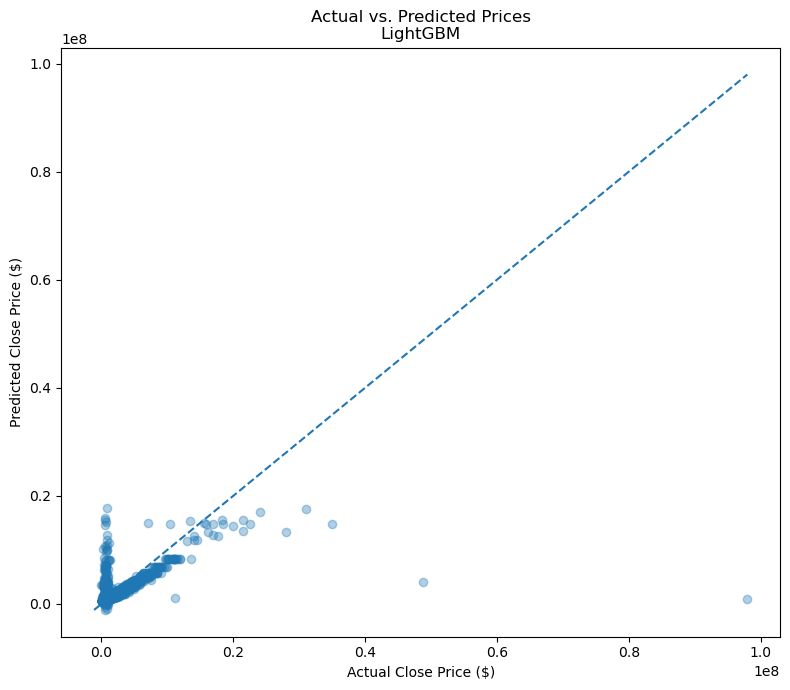

In [29]:
best_predictions = test_predictions[
    best_model_name
]

minimum_price = min(
    float(y_test.min()),
    float(np.min(best_predictions)),
)

maximum_price = max(
    float(y_test.max()),
    float(np.max(best_predictions)),
)

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.35,
)

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--",
)

plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title(
    f"Actual vs. Predicted Prices\n{best_model_name}"
)

plt.tight_layout()
plt.show()

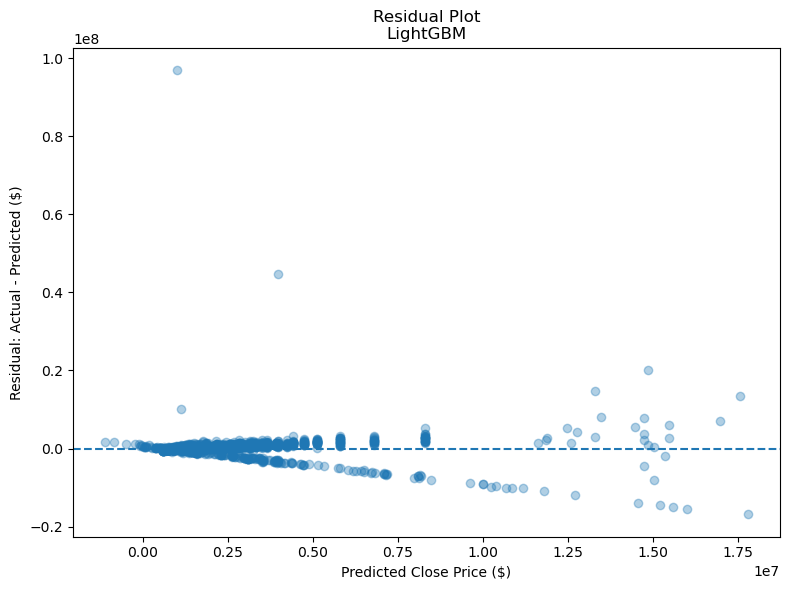

In [30]:
best_residuals = (
    y_test.to_numpy(dtype=float)
    - best_predictions
)

plt.figure(figsize=(8, 6))

plt.scatter(
    best_predictions,
    best_residuals,
    alpha=0.35,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Predicted Close Price ($)")
plt.ylabel("Residual: Actual - Predicted ($)")
plt.title(
    f"Residual Plot\n{best_model_name}"
)

plt.tight_layout()
plt.show()

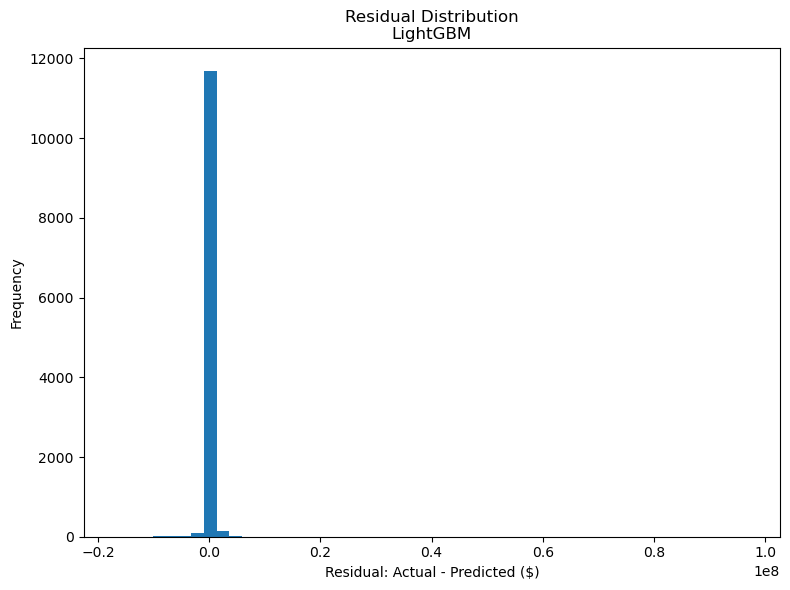

In [31]:
plt.figure(figsize=(8, 6))

plt.hist(
    best_residuals,
    bins=50,
)

plt.xlabel("Residual: Actual - Predicted ($)")
plt.ylabel("Frequency")
plt.title(
    f"Residual Distribution\n{best_model_name}"
)

plt.tight_layout()
plt.show()

In [32]:
importance_frames = []

for model_name, model in trained_models.items():
    if not hasattr(model, "feature_importances_"):
        continue

    model_importance = pd.DataFrame(
        {
            "Model": model_name,
            "Feature": X_train.columns,
            "Importance": model.feature_importances_,
        }
    )

    model_importance = model_importance.sort_values(
        by="Importance",
        ascending=False,
    ).reset_index(drop=True)

    model_importance["Rank"] = (
        model_importance.index + 1
    )

    importance_frames.append(
        model_importance
    )

advanced_feature_importance = pd.concat(
    importance_frames,
    ignore_index=True,
)

advanced_feature_importance.head(20)

,Model,Feature,Importance,Rank
0,Gradient Boosting Reference,OutdoorSpaceApprox,0.3623,1
1,Gradient Boosting Reference,LogListPrice,0.1113,2
2,Gradient Boosting Reference,ListPrice,0.1035,3
3,Gradient Boosting Reference,LivingAreaPerBedroom,0.0868,4
4,Gradient Boosting Reference,LivingAreaPerBathroom,0.0759,5
5,Gradient Boosting Reference,PropertyAgeSquared,0.0649,6
6,Gradient Boosting Reference,PropertyAge,0.0525,7
7,Gradient Boosting Reference,LotToLivingAreaRatio,0.0379,8
8,Gradient Boosting Reference,City_Chula Vista,0.0326,9
9,Gradient Boosting Reference,LivingArea,0.0288,10


In [33]:
for model_name in advanced_feature_importance[
    "Model"
].unique():
    print(f"\nTop features for {model_name}")
    print("-" * 60)

    display(
        advanced_feature_importance[
            advanced_feature_importance["Model"]
            == model_name
        ].head(15)
    )


Top features for Gradient Boosting Reference
------------------------------------------------------------


,Model,Feature,Importance,Rank
0,Gradient Boosting Reference,OutdoorSpaceApprox,0.3623,1
1,Gradient Boosting Reference,LogListPrice,0.1113,2
2,Gradient Boosting Reference,ListPrice,0.1035,3
3,Gradient Boosting Reference,LivingAreaPerBedroom,0.0868,4
4,Gradient Boosting Reference,LivingAreaPerBathroom,0.0759,5
5,Gradient Boosting Reference,PropertyAgeSquared,0.0649,6
6,Gradient Boosting Reference,PropertyAge,0.0525,7
7,Gradient Boosting Reference,LotToLivingAreaRatio,0.0379,8
8,Gradient Boosting Reference,City_Chula Vista,0.0326,9
9,Gradient Boosting Reference,LivingArea,0.0288,10



Top features for XGBoost
------------------------------------------------------------


,Model,Feature,Importance,Rank
988,XGBoost,CountyOrParish_San Bernardino,0.1141,1
989,XGBoost,City_Chula Vista,0.0903,2
990,XGBoost,LivingAreaPerBathroom,0.0761,3
991,XGBoost,PropertyAge,0.0737,4
992,XGBoost,OutdoorSpaceApprox,0.0600,5
993,XGBoost,LivingArea,0.0548,6
994,XGBoost,LivingAreaPerBedroom,0.0536,7
995,XGBoost,LogLivingArea,0.0534,8
996,XGBoost,ListPricePerSquareFoot,0.0493,9
997,XGBoost,LogLotSize,0.0475,10



Top features for LightGBM
------------------------------------------------------------


,Model,Feature,Importance,Rank
1976,LightGBM,ListPrice,604.0000,1
1977,LightGBM,ListPricePerSquareFoot,84.0000,2
1978,LightGBM,OutdoorSpaceApprox,82.0000,3
1979,LightGBM,LivingAreaPerBathroom,71.0000,4
1980,LightGBM,PropertyAge,46.0000,5
1981,LightGBM,LotSizeSquareFeet,40.0000,6
1982,LightGBM,LogListPrice,39.0000,7
1983,LightGBM,City_Lake Elsinore,37.0000,8
1984,LightGBM,City_Victorville,35.0000,9
1985,LightGBM,LivingAreaPerBedroom,33.0000,10


In [34]:
best_model_importance = advanced_feature_importance[
    advanced_feature_importance["Model"]
    == best_model_name
].copy()

if best_model_importance.empty:
    print(
        "The selected model does not provide "
        "feature importance values."
    )
else:
    display(
        best_model_importance.head(20)
    )

,Model,Feature,Importance,Rank
1976,LightGBM,ListPrice,604.0000,1
1977,LightGBM,ListPricePerSquareFoot,84.0000,2
1978,LightGBM,OutdoorSpaceApprox,82.0000,3
1979,LightGBM,LivingAreaPerBathroom,71.0000,4
1980,LightGBM,PropertyAge,46.0000,5
1981,LightGBM,LotSizeSquareFeet,40.0000,6
1982,LightGBM,LogListPrice,39.0000,7
1983,LightGBM,City_Lake Elsinore,37.0000,8
1984,LightGBM,City_Victorville,35.0000,9
1985,LightGBM,LivingAreaPerBedroom,33.0000,10


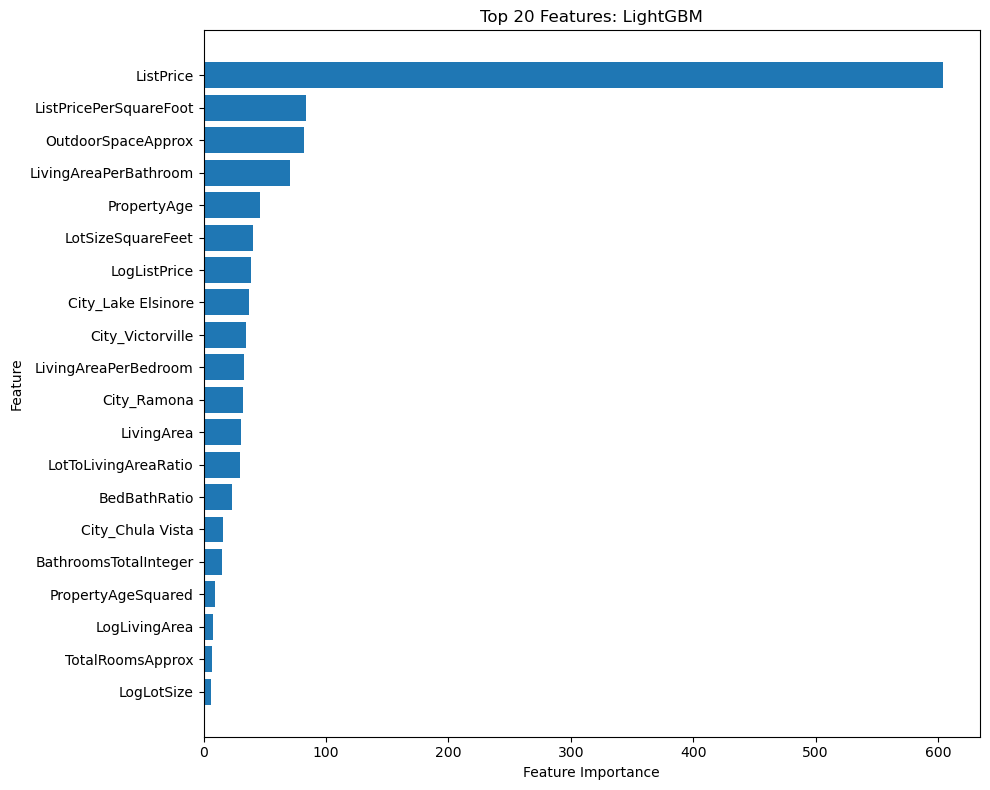

In [35]:
if not best_model_importance.empty:
    top_features = (
        best_model_importance
        .head(20)
        .sort_values(
            by="Importance",
            ascending=True,
        )
    )

    plt.figure(figsize=(10, 8))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"],
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title(
        f"Top 20 Features: {best_model_name}"
    )

    plt.tight_layout()
    plt.show()

In [36]:
engineered_feature_names = {
    "LivingAreaPerBedroom",
    "LivingAreaPerBathroom",
    "BedBathRatio",
    "ListPricePerSquareFoot",
    "LotToLivingAreaRatio",
    "TotalRoomsApprox",
    "OutdoorSpaceApprox",
    "LogLivingArea",
    "LogLotSize",
    "LogListPrice",
    "IsNewProperty",
    "IsRecentProperty",
    "IsOlderProperty",
    "PropertyAgeSquared",
}

if not best_model_importance.empty:
    engineered_importance = (
        best_model_importance[
            best_model_importance["Feature"].isin(
                engineered_feature_names
            )
        ]
        .sort_values(
            by="Importance",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    engineered_importance

In [37]:
prediction_report = pd.DataFrame(
    {
        "ActualClosePrice": (
            y_test.reset_index(drop=True)
        ),
    }
)

for model_name, predictions in test_predictions.items():
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    prediction_column = (
        f"{safe_name}_prediction"
    )

    error_column = (
        f"{safe_name}_absolute_error"
    )

    prediction_report[prediction_column] = predictions

    prediction_report[error_column] = np.abs(
        prediction_report["ActualClosePrice"]
        - prediction_report[prediction_column]
    )

prediction_report.head(10)

,ActualClosePrice,gradient_boosting_reference_prediction,gradient_boosting_reference_absolute_error,xgboost_prediction,xgboost_absolute_error,lightgbm_prediction,lightgbm_absolute_error
0,"8,712,500.0000","8,491,606.7548","220,893.2452","7,666,020.0000","1,046,480.0000","6,811,470.5673","1,901,029.4327"
1,"1,100,000.0000","1,129,928.7414","29,928.7414","1,124,251.5000","24,251.5000","1,140,629.0076","40,629.0076"
2,"1,625,000.0000","1,407,065.1892","217,934.8108","1,343,488.7500","281,511.2500","1,374,446.4894","250,553.5106"
3,"1,560,000.0000","1,505,044.7193","54,955.2807","1,467,961.5000","92,038.5000","1,452,385.1596","107,614.8404"
4,"605,000.0000","703,449.7055","98,449.7055","698,898.1250","93,898.1250","753,617.4245","148,617.4245"
5,"377,500.0000","444,364.1245","66,864.1245","549,719.0000","172,219.0000","638,892.2567","261,392.2567"
6,"400,000.0000","326,943.0069","73,056.9931","538,325.0000","138,325.0000","644,119.6994","244,119.6994"
7,"595,000.0000","608,408.3825","13,408.3825","650,516.6875","55,516.6875","754,776.5883","159,776.5883"
8,"595,000.0000","567,165.3449","27,834.6551","638,042.3750","43,042.3750","754,776.5883","159,776.5883"
9,"2,400,000.0000","2,526,681.1225","126,681.1225","2,405,472.2500","5,472.2500","2,170,770.9586","229,229.0414"


In [38]:
best_safe_name = (
    best_model_name.lower()
    .replace(" ", "_")
    .replace("-", "_")
)

best_prediction_column = (
    f"{best_safe_name}_prediction"
)

best_error_column = (
    f"{best_safe_name}_absolute_error"
)

largest_errors = prediction_report.sort_values(
    by=best_error_column,
    ascending=False,
).head(20)

largest_errors

,ActualClosePrice,gradient_boosting_reference_prediction,gradient_boosting_reference_absolute_error,xgboost_prediction,xgboost_absolute_error,lightgbm_prediction,lightgbm_absolute_error
10192,"97,972,500.0000","1,009,955.9640","96,962,544.0360","1,018,425.1250","96,954,074.8750","1,011,573.3133","96,960,926.6867"
8125,"48,720,000.0000","4,821,132.9826","43,898,867.0174","4,884,894.0000","43,835,106.0000","3,988,688.5504","44,731,311.4496"
46,"35,000,000.0000","28,197,556.4403","6,802,443.5597","12,417,985.0000","22,582,015.0000","14,873,210.2541","20,126,789.7459"
7598,"900,000.0000","14,103,734.7978","13,203,734.7978","33,106,094.0000","32,206,094.0000","17,801,569.1228","16,901,569.1228"
9233,"629,000.0000","8,055,411.1373","7,426,411.1373","43,221,088.0000","42,592,088.0000","15,996,578.7624","15,367,578.7624"
11701,"629,000.0000","785,715.5111","156,715.5111","43,793,228.0000","43,164,228.0000","15,586,554.3129","14,957,554.3129"
391,"28,000,000.0000","23,383,604.2271","4,616,395.7729","18,028,360.0000","9,971,640.0000","13,295,866.0907","14,704,133.9093"
6421,"735,000.0000","-103,477.1854","838,477.1854","60,327,672.0000","59,592,672.0000","15,228,382.8465","14,493,382.8465"
11113,"480,000.0000","17,070,863.6701","16,590,863.6701","-10,530,361.0000","11,010,361.0000","14,560,794.3046","14,080,794.3046"
1727,"31,000,000.0000","28,177,674.9933","2,822,325.0067","24,382,410.0000","6,617,590.0000","17,579,673.2323","13,420,326.7677"


In [39]:
reference_model_file = (
    MODELS_DIR / "reference_model_week7.pkl"
)

xgboost_model_file = (
    MODELS_DIR / "xgboost_model.pkl"
)

lightgbm_model_file = (
    MODELS_DIR / "lightgbm_model.pkl"
)

joblib.dump(
    reference_model,
    reference_model_file,
)

joblib.dump(
    xgboost_model,
    xgboost_model_file,
)

joblib.dump(
    lightgbm_model,
    lightgbm_model_file,
)

print(f"Saved: {reference_model_file}")
print(f"Saved: {xgboost_model_file}")
print(f"Saved: {lightgbm_model_file}")

Saved: C:\Users\sonng\California_Housing_Data\models\reference_model_week7.pkl
Saved: C:\Users\sonng\California_Housing_Data\models\xgboost_model.pkl
Saved: C:\Users\sonng\California_Housing_Data\models\lightgbm_model.pkl


In [40]:
best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "feature_names": X_train.columns.tolist(),
    "target_column": TARGET_COLUMN,
}

best_model_file = (
    MODELS_DIR / "best_advanced_model.pkl"
)

joblib.dump(
    best_model_artifact,
    best_model_file,
)

print(f"Best model artifact saved to: {best_model_file}")

Best model artifact saved to: C:\Users\sonng\California_Housing_Data\models\best_advanced_model.pkl


In [41]:
metrics_file = (
    REPORTS_DIR / "advanced_model_metrics.csv"
)

predictions_file = (
    REPORTS_DIR / "advanced_model_predictions.csv"
)

importance_file = (
    REPORTS_DIR / "advanced_feature_importance.csv"
)

advanced_metrics.to_csv(
    metrics_file,
    index=False,
)

prediction_report.to_csv(
    predictions_file,
    index=False,
)

advanced_feature_importance.to_csv(
    importance_file,
    index=False,
)

print(f"Saved: {metrics_file}")
print(f"Saved: {predictions_file}")
print(f"Saved: {importance_file}")

Saved: C:\Users\sonng\California_Housing_Data\reports\advanced_model_metrics.csv
Saved: C:\Users\sonng\California_Housing_Data\reports\advanced_model_predictions.csv
Saved: C:\Users\sonng\California_Housing_Data\reports\advanced_feature_importance.csv


In [42]:
metadata = {
    "model_name": best_model_name,
    "target_column": TARGET_COLUMN,
    "feature_count": int(X_train.shape[1]),
    "selection_metric": "RMSE",
    "validation_strategy": (
        "Final 20 percent of the training period"
    ),
    "test_metrics": {
        "MAE": float(best_metrics["MAE"]),
        "RMSE": float(best_metrics["RMSE"]),
        "MAPE": float(best_metrics["MAPE"]),
        "MdAPE": float(best_metrics["MdAPE"]),
        "R2": float(best_metrics["R2"]),
    },
}

metadata_file = (
    REPORTS_DIR
    / "best_advanced_model_metadata.json"
)

with open(
    metadata_file,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=4,
    )

print(f"Saved: {metadata_file}")

Saved: C:\Users\sonng\California_Housing_Data\reports\best_advanced_model_metadata.json


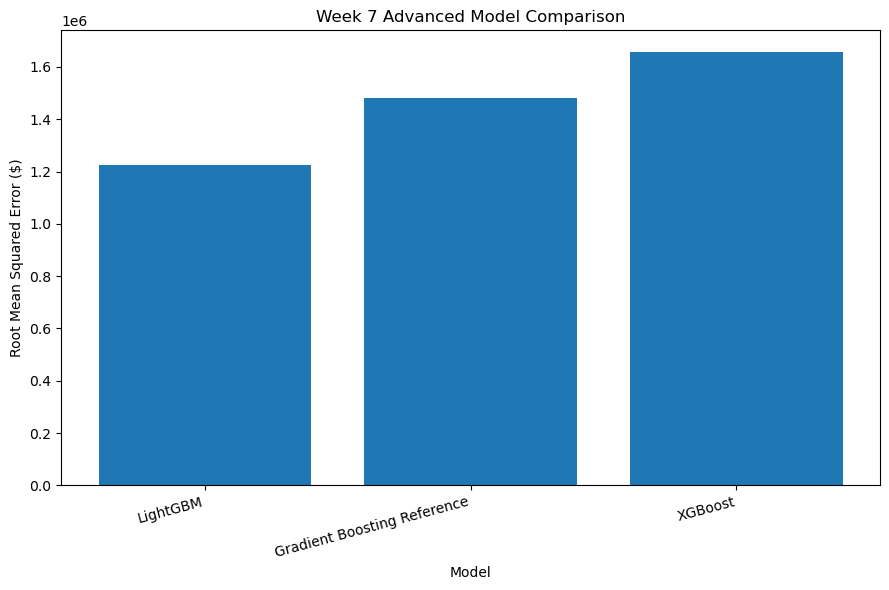

Saved: C:\Users\sonng\California_Housing_Data\reports\advanced_model_comparison.png


In [43]:
comparison_figure_file = (
    REPORTS_DIR / "advanced_model_comparison.png"
)

plot_metrics = advanced_metrics.sort_values(
    by="RMSE",
    ascending=True,
)

plt.figure(figsize=(9, 6))

plt.bar(
    plot_metrics["Model"],
    plot_metrics["RMSE"],
)

plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error ($)")
plt.title("Week 7 Advanced Model Comparison")

plt.xticks(
    rotation=15,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    comparison_figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {comparison_figure_file}")

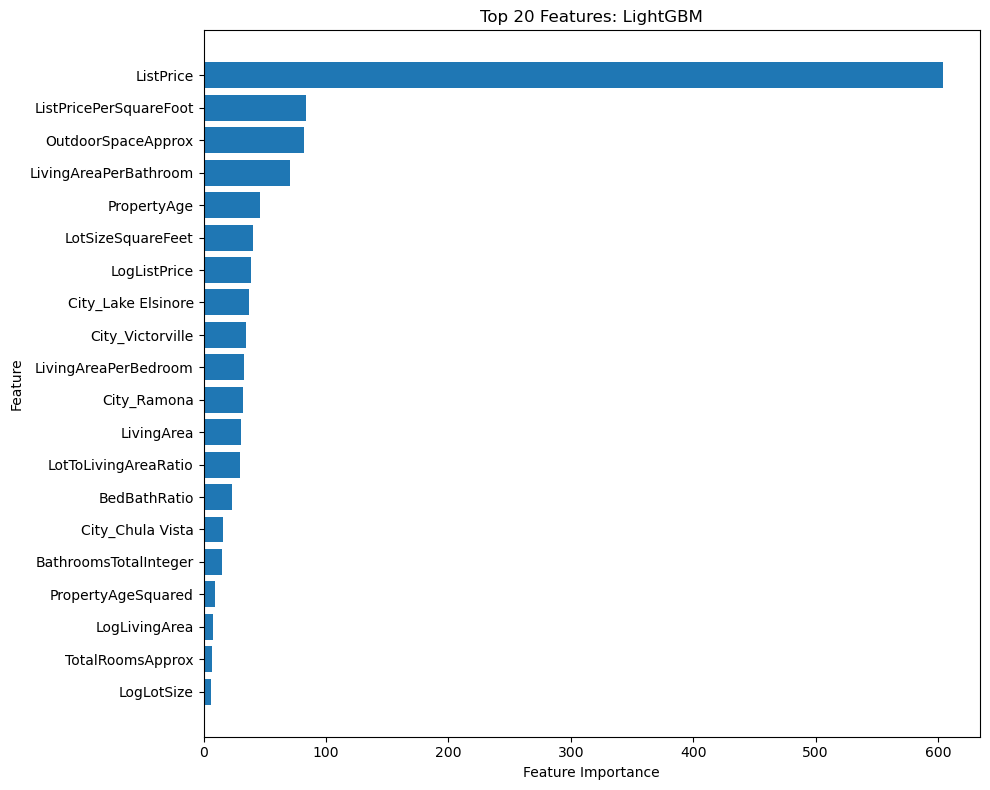

Saved: C:\Users\sonng\California_Housing_Data\reports\advanced_feature_importance.png


In [44]:
importance_figure_file = (
    REPORTS_DIR
    / "advanced_feature_importance.png"
)

if not best_model_importance.empty:
    top_features = (
        best_model_importance
        .head(20)
        .sort_values(
            by="Importance",
            ascending=True,
        )
    )

    plt.figure(figsize=(10, 8))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"],
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title(
        f"Top 20 Features: {best_model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        importance_figure_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved: {importance_figure_file}")

In [45]:
best_row = advanced_metrics.iloc[0]
second_row = advanced_metrics.iloc[1]

rmse_difference = (
    second_row["RMSE"]
    - best_row["RMSE"]
)

mae_difference = (
    second_row["MAE"]
    - best_row["MAE"]
)

r2_difference = (
    best_row["R2"]
    - second_row["R2"]
)

print("Week 7 Results")
print("=" * 60)

print(
    f"The strongest model was {best_row['Model']}."
)

print(
    f"It achieved an MAE of "
    f"${best_row['MAE']:,.2f}."
)

print(
    f"It achieved an RMSE of "
    f"${best_row['RMSE']:,.2f}."
)

print(
    f"Its MAPE was "
    f"{best_row['MAPE']:.2f}%."
)

print(
    f"Its median percentage error was "
    f"{best_row['MdAPE']:.2f}%."
)

print(
    f"Its R² score was "
    f"{best_row['R2']:.4f}."
)

print(
    f"\nCompared with {second_row['Model']}, "
    f"the best model reduced RMSE by "
    f"${rmse_difference:,.2f}."
)

print(
    f"It reduced MAE by "
    f"${mae_difference:,.2f}."
)

print(
    f"Its R² score was higher by "
    f"{r2_difference:.4f}."
)

Week 7 Results
The strongest model was LightGBM.
It achieved an MAE of $284,937.71.
It achieved an RMSE of $1,226,080.43.
Its MAPE was 35.97%.
Its median percentage error was 15.71%.
Its R² score was 0.4661.

Compared with Gradient Boosting Reference, the best model reduced RMSE by $255,844.27.
It reduced MAE by $-108,409.96.
Its R² score was higher by 0.2460.


# Week 7 Summary

This notebook compared a traditional Gradient Boosting model with two
advanced gradient-boosting frameworks:

- XGBoost
- LightGBM

## Validation design

The original chronological test set remained untouched. The final 20%
of the training observations was used as a chronological validation set
for early stopping.

## Evaluation metrics

The models were compared using:

- Mean Absolute Error
- Root Mean Squared Error
- Mean Absolute Percentage Error
- Median Absolute Percentage Error
- R²
- Training time
- Prediction time

## Model selection

The final model was selected primarily using the lowest test RMSE.
R² was used as a secondary comparison metric.

## Outputs

The notebook saved:

- Each individual trained model
- A best-model artifact
- Model metrics
- Test predictions
- Feature importance
- Model comparison charts
- Best-model metadata

## Next step

Week 8 will focus on systematic hyperparameter tuning and validation
rather than relying only on manually selected model settings.